In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load dataset 
df = pd.read_csv("Local_Area_Unemployment_Statistics__Beginning_1976.csv")

In [4]:
df.head()

,Area,Year,Month,Labor Force,Employed,Unemployed,Unemployment Rate
0,New York State,2025,1,9777800,9327700,450000,4.6
1,New York State,2025,2,9841900,9415800,426000,4.3
2,New York State,2025,3,9885800,9481300,404500,4.1
3,New York State,2025,4,9875900,9515200,360700,3.7
4,New York State,2025,5,9816500,9473800,342600,3.5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94028 entries, 0 to 94027
Data columns (total 7 columns):
 #   Column                                                                                                                                                                                   Non-Null Count  Dtype  
---  ------                                                                                                                                                                                   --------------  -----  
 0   Area                                                                                                                                                                                     94028 non-null  object 
 1   Year                                                                                                                                                                                     94028 non-null  int64  
 2   Month                          

In [6]:
print(df.isnull().sum())

Area                                                                                                                                                                                       0
Year                                                                                                                                                                                       0
Month                                                                                                                                                                                      0
Labor Force                                                                                                                                                                                0
Employed                                                                                                                                                                                   0
Unemployed                                             

In [7]:
df.columns = df.columns.str.strip()
df = df.dropna(subset=['Unemployment Rate'])

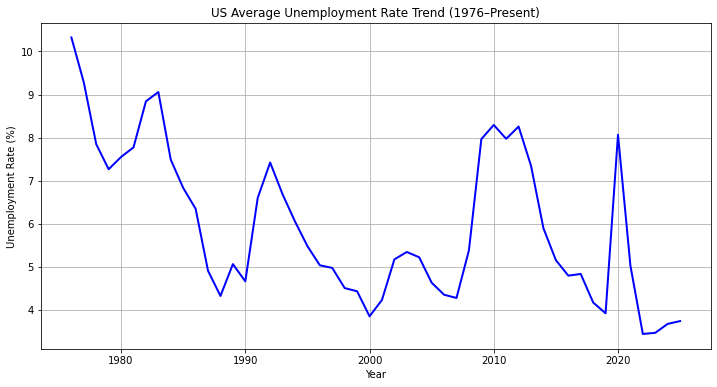

In [9]:
# National average unemployment rate per month
national_trend = df.groupby('Year')['Unemployment Rate'].mean()

plt.figure(figsize=(12,6))
plt.plot(national_trend, color='blue', linewidth=2)
plt.title("US Average Unemployment Rate Trend (1976–Present)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

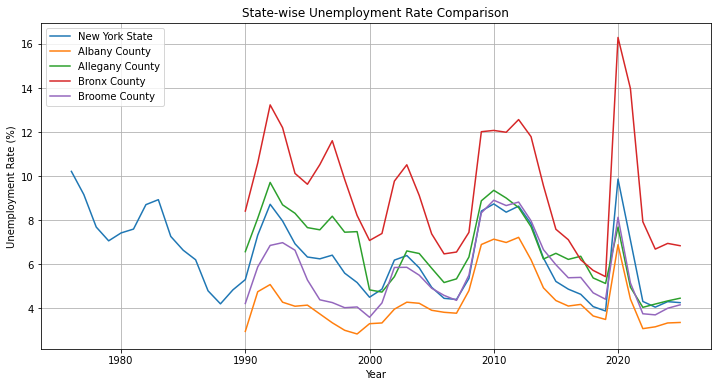

In [11]:
states = df['Area'].unique()[:5]
plt.figure(figsize=(12,6))

for state in states:
    state_data = df[df['Area'] == state].groupby('Year')['Unemployment Rate'].mean()
    plt.plot(state_data, label=state)

plt.title("State-wise Unemployment Rate Comparison")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

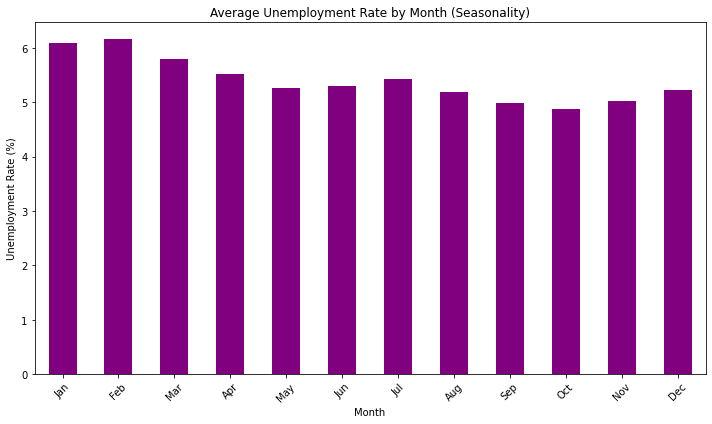

In [15]:
import calendar #this is imported for the month name as the dataset had month as 1,2,3...
month_avg = df.groupby('Month')['Unemployment Rate'].mean()

# convertd month numbers to month names for better visual
month_names = [calendar.month_abbr[i] for i in range(1, 13)]
month_avg.index = month_names

plt.figure(figsize=(10,6))
month_avg.plot(kind='bar', color="purple")
plt.title("Average Unemployment Rate by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

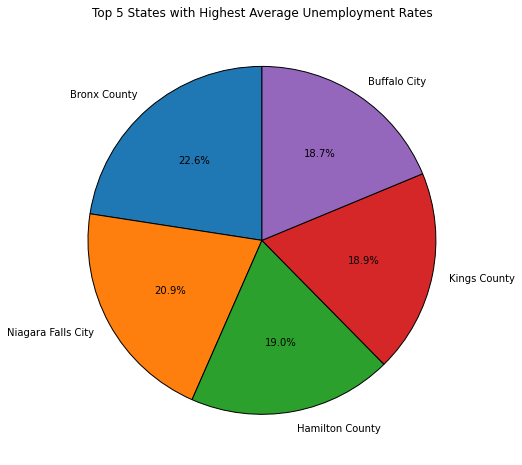

In [18]:
Area_avg = df.groupby('Area')['Unemployment Rate'].mean().sort_values(ascending=False)
# Select top 5 states 
top_5_states_avg = Area_avg.head(5) 
plt.figure(figsize=(10, 8)) 
plt.pie(top_5_states_avg, labels=top_5_states_avg.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'}) 
plt.title("Top 5 States with Highest Average Unemployment Rates") 
plt.show()

In [19]:
state_avg = df.groupby('Area')['Unemployment Rate'].mean().sort_values(ascending=False)

print("Top 5 states with highest average unemployment:")
print(state_avg.head())

print("\nTop 5 states with lowest average unemployment:")
print(state_avg.tail())

Top 5 states with highest average unemployment:
Area
Bronx County          9.365661
Niagara Falls City    8.661021
Hamilton County       7.870766
Kings County          7.836891
Buffalo City          7.782367
Name: Unemployment Rate, dtype: float64

Top 5 states with lowest average unemployment:
Area
Clifton Park Town    3.509281
Guilderland Town     3.345244
Brighton Town        3.329930
Bethlehem Town       3.293503
Pittsford Town       3.270534
Name: Unemployment Rate, dtype: float64
